In [ ]:
# # MSML610 Project 3: Fairness in Predictive Policing (UmdTask187)
# # Example Notebook: End-to-End Workflow Demonstration (Midterm Check-in
# # This notebook demonstrates the plan to load data, train the fair model, 
# # and evaluate intersectional fairness metrics. The data is currently mocked 
# # using placeholder functions in FairnessPP_utils.py.

# # --- 1. SETUP AND IMPORTS ---
# # Import core libraries and your custom functions from the utility module.
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from FairnessPP_utils import load_and_preprocess_data, train_fair_model, evaluate_fairness



In [ ]:
# # --- 2. DATA PREPARATION AND SPLIT ---
# # Note: The actual Chicago Crime Data is not committed to the repository, 
# # so the utility function loads a structural placeholder.
# DATA_PATH = "data/chicago_crime_data.csv"

# # Load data, engineer features, and define the Intersectional Sensitive Attribute (A)
# # A = Race_Income
# X, y, A = load_and_preprocess_data(DATA_PATH)

# print(f"Total Records: {X.shape[0]}")
# print(f"Features (X) Preview:\n{X.head(2)}\n")
# print(f"Sensitive Attribute (A) Groups:\n{A.unique()}")

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
#     X, y, A, test_size=0.3, random_state=42
# )

# print(f"\nTraining set size: {X_train.shape[0]}")
# print(f"Testing set size: {X_test.shape[0]}")

Total Records: 100
Features (X) Preview:
   Crime_Density_Log  Police_Visits_Avg
0           2.113525                 13
1           1.538592                 41

Sensitive Attribute (A) Groups:
['White_Medium' 'White_High' 'Black_Medium' 'White_Low' 'Asian_Medium'
 'Hispanic_High' 'Hispanic_Low' 'Black_Low' 'Black_High' 'Asian_High'
 'Hispanic_Medium' 'Asian_Low']

Training set size: 70
Testing set size: 30


In [ ]:
# # --- 4. INTERSECTIONAL FAIRNESS EVALUATION ---
# # Evaluate performance and disparity across intersectional groups (A_test).

# group_metrics, eq_odds_diff = evaluate_fairness(fair_model, X_test, y_test, A_test)

# print("\n=======================================================")
# print("Mock Evaluation Results (Midterm Check-in Structure)")
# print("=======================================================")
# print("\nMetrics by Intersectional Group (TPR/FPR/Accuracy):")
# # Displaying the results clearly shows the planned comparison across groups
# print(group_metrics)

# print(f"\nEqualized Odds Difference (Overall Fairness Metric): {eq_odds_diff:.4f}")
# print("Target: The final project will analyze the trade-offs between overall performance")
# print("and reducing this difference below a threshold (e.g., < 0.10).")

# # --- END OF NOTEBOOK ---

In [ ]:
# # --- 4. INTERSECTIONAL FAIRNESS EVALUATION ---
# # Evaluate performance and disparity across intersectional groups (A_test).

# group_metrics, eq_odds_diff = evaluate_fairness(fair_model, X_test, y_test, A_test)

# print("\n=======================================================")
# print("Mock Evaluation Results (Midterm Check-in Structure)")
# print("=======================================================")
# print("\nMetrics by Intersectional Group (TPR/FPR/Accuracy):")
# # Displaying the results clearly shows the planned comparison across groups
# print(group_metrics)

# print(f"\nEqualized Odds Difference (Overall Fairness Metric): {eq_odds_diff:.4f}")
# print("Target: The final project will analyze the trade-offs between overall performance")
# print("and reducing this difference below a threshold (e.g., < 0.10).")



=== Step 1: Data Ingestion ===
Fetching multi-year data from Chicago API...
 - Fetching 2020...
API Error: URL can't contain control characters. '/resource/ijzp-q8t2.json?$limit=20000&year=2020&$order=date DESC' (found at least ' '). Generating Mock Data.
Total Records: 2000

=== Step 2: Demographics Analysis ===


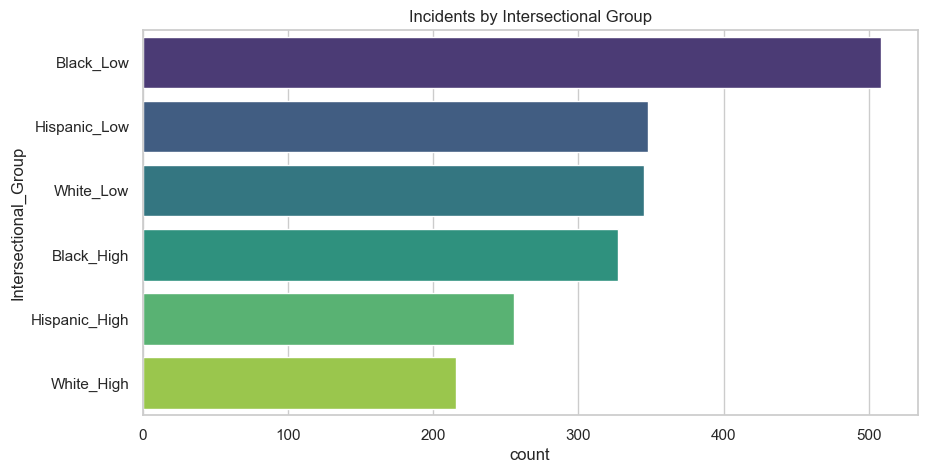


=== Step 3: Temporal Data Splitting ===
Training Set (2020-2022): 1096 rows
Test Set (2023): 365 rows

=== Step 4: Training Baseline Model ===
Training Baseline Model (Native GradientBoosting)...

=== Step 5: Training Fair Model ===
Training Mitigated Model (Fairlearn ExponentiatedGradient)...

=== Step 6: Final Comparison ===


,Model,Accuracy,Balanced_Acc,Fairness_Disparity
0,Baseline (Unmitigated),0.473973,0.473115,0.393888
1,Fair (Mitigated),0.465753,0.465875,0.224109


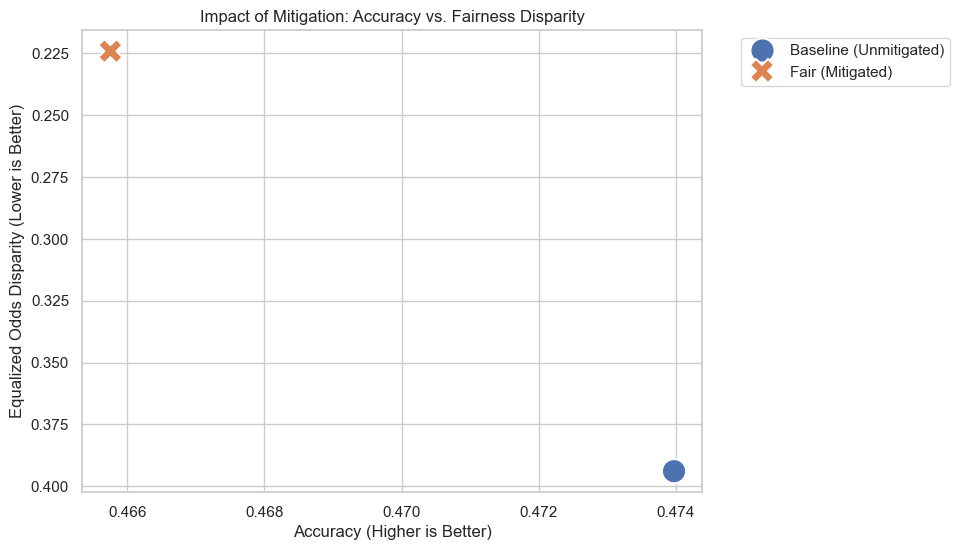

Disparity Breakdown for Fair Model:


,Selection Rate,Accuracy
Intersectional_Group,,
Black_High,0.483333,0.483333
Black_Low,0.494118,0.494118
Hispanic_High,0.568182,0.500000
Hispanic_Low,0.531250,0.421875
White_High,0.487805,0.536585
White_Low,0.478873,0.394366


In [1]:
# Cell 1: Imports & Setup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from FairnessPP_utils import load_chicago_data, FairnessPredictor, ModelConfig
from IPython.display import display

sns.set_theme(style="whitegrid")

# Cell 2: Data Ingestion
# Using the utility function to handle API and Caching
print("=== Step 1: Data Ingestion ===")
X, y, A, dates = load_chicago_data()
print(f"Total Records: {len(X)}")

# Cell 3: Exploratory Analysis
print("\n=== Step 2: Demographics Analysis ===")
plt.figure(figsize=(10, 5))
sns.countplot(y=A, order=A.value_counts().index, palette="viridis")
plt.title("Incidents by Intersectional Group")
plt.show()

# Cell 4: Temporal Splitting
print("\n=== Step 3: Temporal Data Splitting ===")
# Train on 2020-2022, Test on 2023
train_mask = dates.dt.year < 2023
test_mask = dates.dt.year == 2023

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
A_train, A_test = A[train_mask], A[test_mask]

print(f"Training Set (2020-2022): {X_train.shape[0]} rows")
print(f"Test Set (2023): {X_test.shape[0]} rows")

# Cell 5: Initialize Wrappers
# We use our custom wrapper API instead of raw Sklearn
config = ModelConfig(n_estimators=50, max_iter_mitigation=50)

baseline_model = FairnessPredictor(config)
fair_model = FairnessPredictor(config)

# Cell 6: Train Baseline
print("\n=== Step 4: Training Baseline Model ===")
baseline_model.train(X_train, y_train, mitigate=False)
baseline_result = baseline_model.evaluate(X_test, y_test, A_test)

# Cell 7: Train Fair Model
print("\n=== Step 5: Training Fair Model ===")
fair_model.train(X_train, y_train, A=A_train, mitigate=True)
fair_result = fair_model.evaluate(X_test, y_test, A_test)

# Cell 8: Comparative Results
print("\n=== Step 6: Final Comparison ===")

comparison_data = [
    {
        "Model": "Baseline (Unmitigated)",
        "Accuracy": baseline_result.accuracy,
        "Balanced_Acc": baseline_result.balanced_accuracy,
        "Fairness_Disparity": baseline_result.fairness_disparity
    },
    {
        "Model": "Fair (Mitigated)",
        "Accuracy": fair_result.accuracy,
        "Balanced_Acc": fair_result.balanced_accuracy,
        "Fairness_Disparity": fair_result.fairness_disparity
    }
]

results_df = pd.DataFrame(comparison_data)
display(results_df)

# Cell 9: Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=results_df, 
    x='Accuracy', 
    y='Fairness_Disparity', 
    hue='Model', 
    style='Model', 
    s=300
)
plt.title("Impact of Mitigation: Accuracy vs. Fairness Disparity")
plt.xlabel("Accuracy (Higher is Better)")
plt.ylabel("Equalized Odds Disparity (Lower is Better)")
plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Cell 10: Deep Dive into Group Disparities
print("Disparity Breakdown for Fair Model:")
display(fair_result.group_metrics)